# Guide to using Git
Git is a tool for versioning code and for collaborating on software projects. It is the tool enabling you to share code on sites like Github. Git is used in virtually every software project on earth (big or small) to organize code and to enable parallel collaboration between developers. Git has four primary commands that are essential to know. These are *add*, *commit*, *push*, and *pull*, each are explained in the following sections.

On top of that, there are four "copies" of the project to be aware of. There are your local files and folders, then there is the staging area where files to be added to the project are tracked, then there is your local repository, and finally there is the remote repository on Github. This is illustrated in the diagram below.

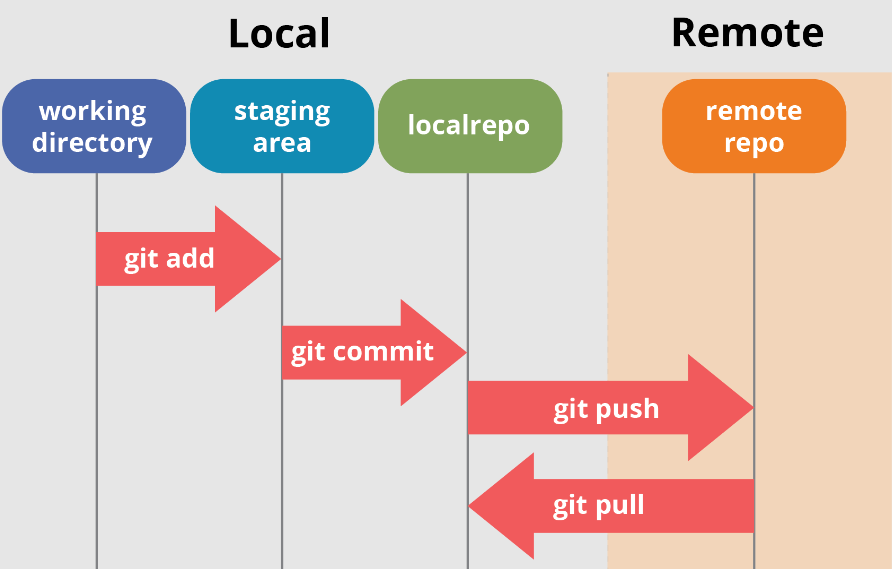

The basic git commands are explained below. Before you start running these, you should read the whole guide as there are important details in the sections [Working with Git branches and Pull Requests](#working-with-branches-and-pull-requests) and [Best Practices](#best-practices). Any of the following commands can be done either in **VS Code** using the Source Control panel on the left or in the terminal using the commands shown below. The terminal commands are included so there is always a clear fallback if the graphical interface is confusing.

## 1) Add
The git *add* command adds the files you've edited in the project to the *staging area* where files you intend to *commit* in the future are stored.

This can be done with the following command in Git:
```bash
git add <file_or_folder>
```

or simply
```bash
git add .
```

to add everything you've changed. But be mindful of what is actually being added. You can run the following command to see what is changed and staged:
```bash
git status
```

If you're using VSCode to interact with Git through the 'Source Control' widget in the sidebar, you can click the **+** next to a changed file to add it instead.

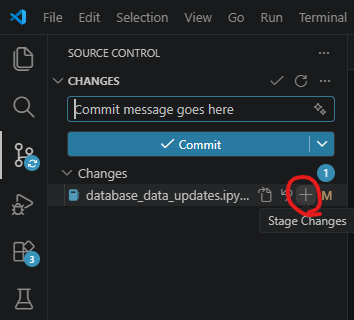

## 2) Commit
Once you're ready to merge your changes into the local repository, you run the following command:

```bash
git commit -m "<some_message_here>"
```

This adds all the staged files to your local repository and creates a "snapshot", so you can always revert to the state the project was in at that commit. You have to write a message here, which can be anything, but should ideally describe what was done in the commit.

In VSCode you usually *add* and *commit* at the same time:

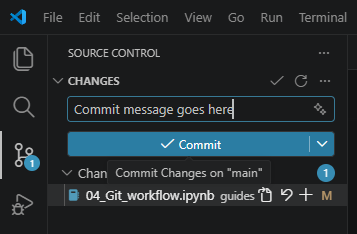


## 3) Push
To push your commit to the remote repository, so other people can see your changes and collaborate with you, you run the following command:

```bash
git push
```

which pushes all the commits you've made since your last push to the remote repository on Github.

In VScode this is done by clicking here:

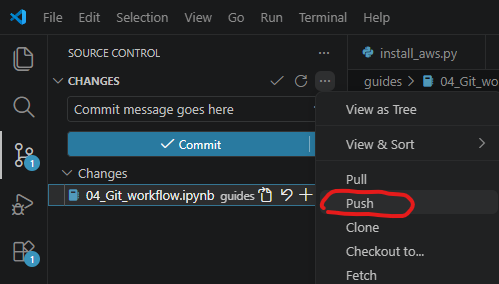

You can also commit and push immediately, by clicking here:

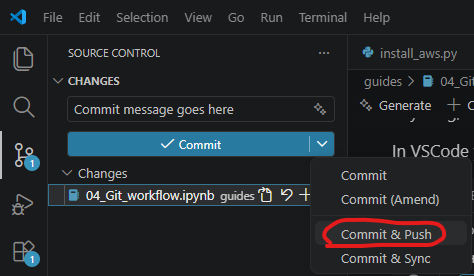

## 4) Pull
To pull changes other people have made from the remote repository to your local repository, run the following command:

```bash
git pull
```

or do the clicky thing in VSCode.

This merges changes made by other people with your local changes.

### Merge Conflicts
Sometimes, pulling might cause problems if you've changed the same files as someone else. This will lead to what's called a *merge conflict*. Here, Git will make it clear to your that some files were changed by both you and someone else and that you need to manually decide which changes to keep. This is most easily done in VSCode, since the editor will highlight where in the file the conflicting changes are and will let you decide what to do.

Once you've resolved the conflicts, commit the changes and push them and you should be good. If you're unsure what to do, feel free to ask for help :)

# Working with Branches and Pull Requests
When working multiple people on the same project, it is very benefitial to do so in a particular way to avoid conflicting changes and to avoid accidently breaking something when making changes.

The most common way to do that is by using *branches* and *pull requests*. A branch in Git is a copy of the entire project, where changes can be made without impacting everyone else. All git projects have a main (or master) branch that is the definitive, official copy of the project. By proper software engineering standards, when code is pushed to the main branch, it is supposed to be functional, well-tested, and ready to share with the world. Therefore, when developing code by your own, you don't want to push directly to the main branch before you're confident your changes works and are complete.

## Branches
In order to develop your code without inteferring with the main branch, you can create your own personal branch (copy of the project) where you can make all the changes you want without worry. Then, when the changes are complete, you merge that branch into the main branch to finalize and publish your changes. Before creating a new branch make sure to run git pull to ensure what you're working on is up to date.

Creating a new branch is done with the following command in a terminal in the project:
```bash
git checkout -b <branch_name>
```

or in VSCode:

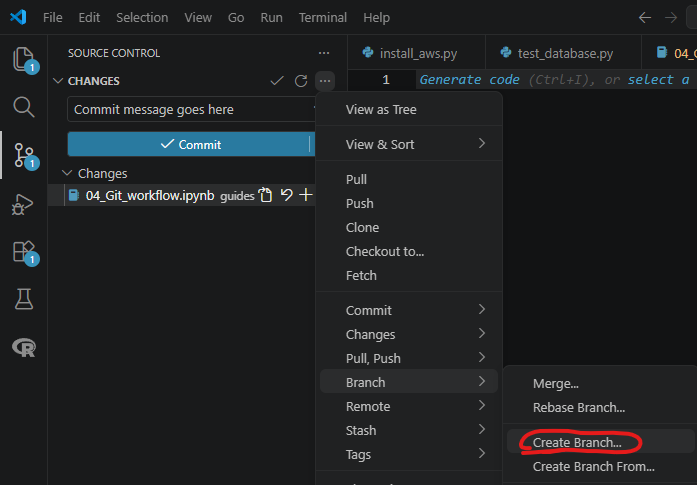

where the branch name can be anything, but should ideally be a short description of the change/feature you're working on, f.x. `awesome_workflow_feature` or something. This creates the branch and switches to it. Now every change you commit and push will only affect that branch and your copy of the project.

Rule of thumb: **one task = one branch = one pull request**.

Some examples of names for branches:
- `add_unit_operation_U-0-42`
- `create_workflow_W-0-Something-something`
- `fix_error_in_some_workflow`
- `add_missing_something_to_something`

When you push to a new branch for the first time, you have to write the following command:
```bash
git push --set-upstream origin <branch_name>
```

which instructs git to create the same branch on Github and to link that remote branch with your local one, so you can sync changes remotely. If you use VSCode, this should happen automatically.

It's a good idea to regularly pull changes from the main branch into your local branch, so your local version of the project is up to date with the main one. This will make it easier when you need to merge your changes into the main branch later on. To do this, run the following command:
```bash
git pull origin main
```

or in VSCode, select 'main' in the 'Pull From' option:

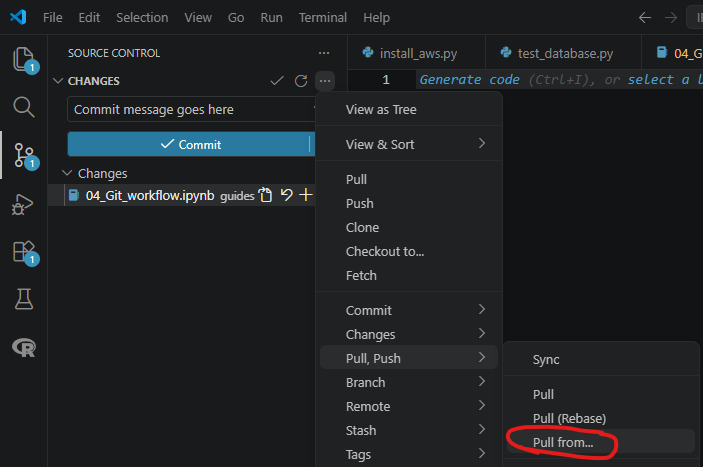

## Pull Requests
When you're confident that the changes you've made in your branch is correct, you will merge them into the main branch. This is done by creating a pull request on Github. To do so, first push all your changes on your local branch to make sure everything is up to date. Then go to the project on Github and click on Pull Requests like so:

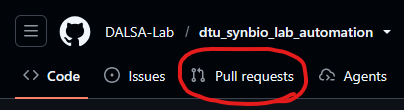

Then click, 'New Pull Request' and select your branch that you want to merge into the main branch.

After creating the PR, you can see an overview of the changes you've made. Here you should quickly verify that everything looks correct and that you haven't made any unintended changes or forgot to push intended changes.

You can also add other people as optional or required "reviewers", if you would like a specific person to read through your changes before you merge them into the main branch.

# Best Practices
Below are some tips & tricks and best practices to follow when using Git.

## Don't commit data
Git is designed to handle code, text, and perhaps an image here or there, but not large amounts of data, such as large excel sheets, binary files, videos, etc. Adding large files will quickly make it super slow to pull changes from the remote repository which is annoying for everyone. Data belongs in a database or on remote drives, where your code can interact with it. You can commit small CSV files or images, but as a rule, anything above a few megabytes should not be added to Git.

## Don't commit sensitive information
Once you push something to the remote repository, it is viewable by everyone in the project and is almost impossible to remove again without recreating the entire Git history and project, which is a massive pain to do. Git is designed to never lose data, which is usually a good thing, but if you commit a password or something, it will be very hard to remove. If your code needs a password to run, you should store the password in a separate file and add that file to the `.gitignore` file in the root of the project. This way, git will never add that password file to the project and you should be save.

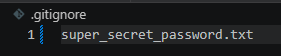

Adding a file to .gitignore will grey it out in the editor, showing that Git ignores it:

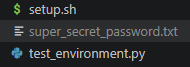

## Generally
Commit intentionally when useful for traceability or FAIR data:

- Final workflow output CSV files for a real campaign/run
- Simulation transcripts that document what was tested before running on the robot
- Input CSV files used to generate a campaign or workflow run

If the list includes generated outputs or cache files, pause before staging them. Ask: is this a final record for the campaign/run, or just a temporary local file? If it is only temporary, do not commit it.

If you're making that change that feels risky or you're unsure, create a commit as a checkpoint, that way you can always return to that point.